# Python
> Native arrays, callable functions and Python conversions.

In [1]:
from basedpl import apl, fn, Array, plus, tally
import numpy as np

## Native arrays

`apl` is the APL workspace. It keeps its names for the life of the Python process. Calling it returns a native `basedpl.Array`. Its immutable data retains nesting, exact numbers and empty-array prototypes. Use `.np` or `.py` to convert it.

In [2]:
v = apl('1 2 4')
v

1 2 4

Python operators use bAsedPL's array semantics. Python determines precedence, so this multiplies before adding:

In [3]:
v * 2 + 1

3 5 9

Indexing is one-based, as in APL. Negative positions count from the end. A full `:` selects an axis. Iteration yields rows of a matrix rather than individual elements:

In [4]:
a = apl('2 3⍴⍳6')
a.shape, a[1, :], a[:, 2], a[:, -1], list(a)

((2, 3), [1., 2., 3.], [2., 5.], [3., 6.], [[1., 2., 3.], [4., 5., 6.]])

bAsedPL also exposes functions by their word names. `plus.reduce` is `+/`; adding `.each` applies it to each nested element:

In [5]:
nested = apl('(1 2)(3 4 5)')
nested

(1 2) (3 4 5)

In Python, chain the corresponding word functions:

In [6]:
plus.reduce.each(nested)

3 12

In [7]:
f = plus.reduce.each
f(nested)

3 12

Python integers become exact values. Functions compose too: `plus.reduce / tally` builds the mean function `+/÷≢`. Its result is still a native array, even when scalar:

In [8]:
exact = Array([1, 2, 4])
mean_native = plus.reduce / tally
mean_native(exact)

7r3

The native representation uses Python numeric notation: `2` is exact and `2.` is approximate. `.apl` returns the APL display as a string:

In [9]:
v.apl, exact.apl

('1 2 4', '1ₓ 2ₓ 4ₓ')

## The workspace

`apl` is shared by the whole Python process, including the [notebook magics](notebooks.ipynb). `apl(']clear')` removes every name and restores the starting display settings.

Calling `apl` returns a native array or function and prints explicit APL output. It suppresses implicit APL display. Use `.np` or `.py` when you need a converted result:

In [10]:
apl('3 3⍴⍳9').np

array([[1., 2., 3.],
       [4., 5., 6.],
       [7., 8., 9.]])

Module and `apl` attributes expose the builtins. Glyph names (`add`, `dash`, `mul`, `div`) accept either valence; operation names (`plus`, `subtract`, `times`, `divide`) curry a dyadic call. Thus `add` with one argument conjugates, while `plus(2)` binds the right argument:

In [11]:
apl.add(2+3j).py, apl.plus(2)(3).py, apl.times(2)([1, 2, 3]).py

((2-3j), 5, array([2, 4, 6]))

Keyword arguments bind Python values in the workspace. Square brackets read an APL expression or assign a value:

In [12]:
apl(x=np.arange(1, 6))
apl['v'] = [3,1,4,1,5]
apl['{[⍋⍵]⌷⍵}v'].np

array([1, 1, 3, 4, 5])

`fn` makes a composable `Function` from an APL function expression. It is the same as `apl.fn`. Pass one argument for a monadic call or two for a dyadic call. Python integers stay exact, so `.py` converts this mean to a `Fraction` rather than a float:

In [13]:
apl('mean←{⍝ Mean of a vector\n(+/⍵)÷≢⍵}')
mean = fn('mean')
mean([1,2,4]).py

Fraction(7, 3)

### Names and help

Type `mean?` for its comment help and `mean??` for APL source. The same information is available programmatically:

In [14]:
mean.source, apl.names('me')

('{⍝ Mean of a vector\n(+/⍵)÷≢⍵}', ['mean'])

See [names and help](introspection.ipynb) for source lookup, erasure and inspection APIs.

`fn` is late-bound: `fn("foo")` follows later redefinitions of `foo`. Use `apl("foo")` to retain its current function.

Calls print only explicit output (`⎕←` and display commands). A second argument of `'explicit'` captures it instead, returning a `Result` with the native `.value` and the captured `.output`:

In [15]:
r = apl('⎕←x ⋄ x+1x', 'explicit', x=3)
assert r.value.py == 4
assert r.output == ['3ₓ']

`'repl'` also captures implicit expression display, as the APL prompt shows it. The `%%apl` cell magic uses it. In ordinary Python notebooks, append `;` to suppress display of a call's return value.

## Labelled arrays

In [16]:
data = [[10, 20, 30], [40, 50, 60]]
keys = ('NY', 'LA'), ('Jan', 'Feb', 'Mar')
sales = Array(data, axis_keys=keys, axis_names=('city', 'month'))
sales.axis_names, sales.axis_keys

(('city', 'month'), (('NY', 'LA'), ('Jan', 'Feb', 'Mar')))

Arithmetic matches named axes and aligns their keys, rather than relying on order. This adjustment lists the months backwards but still adds 1 to January, 2 to February and 3 to March in each city. `.df` copies the result to pandas, preserving labels; install pandas to use it.

In [17]:
months = 'Mar', 'Feb', 'Jan'
adjustment = Array([3, 2, 1], axis_keys=(months,), axis_names=('month',))
(sales + adjustment).df

month,Jan,Feb,Mar
city,,,
NY,11,22,33
LA,41,52,63


## Plots

`plot` draws a chart from an array, and the result displays as that chart. Keys label the x axis and the legend, and axis names title them. Keyword arguments give its settings, with dictionaries for nested ones:

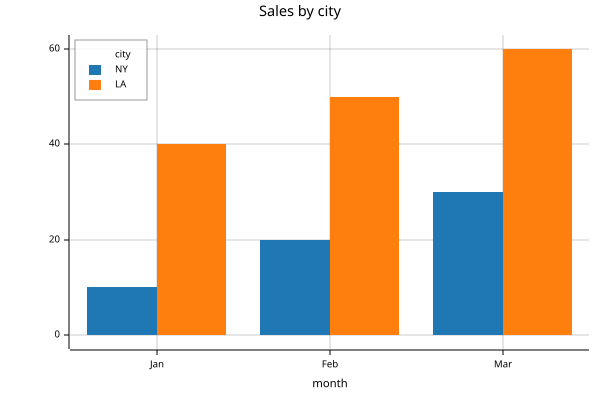

In [18]:
legend = {'position': 'top-left'}
apl.plot(sales, mark='bar', title='Sales by city', legend=legend)

A dict of equal-length lists is a table. Its `x` column supplies the x values, and every other column is a series. [Plots](plot.ipynb) lists all the settings.

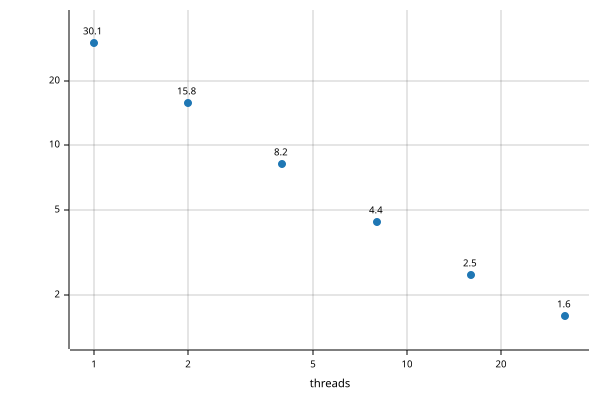

In [19]:
threads = [1, 2, 4, 8, 16, 32]
seconds = [30.1, 15.8, 8.2, 4.4, 2.5, 1.6]
apl.plot({'x': threads, 'seconds': seconds}, mark='point', labels=1,
         x={'title': 'threads', 'scale': 'log'}, y={'scale': 'log'})

## Values and conversion

`Array` retains atoms, shape, nesting, numeric domain and empty prototypes. `.is_atom` distinguishes an atom from a rank-zero array; both have `.shape == ()`. `.apl` is APL display. `.py` converts atoms to Python values and character vectors to strings. Other arrays become NumPy arrays, including rank-zero arrays. `.np` always returns an ndarray.

For [axis-keyed arrays](keyed.qmd), `.py` returns a dict at rank 1 and a pandas DataFrame at higher ranks. `.np` copies the values. Attach labels with `Array(data, axis_keys=[rows, cols])`; use `None` for an unkeyed axis. `.axis_keys` returns a tuple of label tuples or `None`.

`axis_names` names dimensions; `axis_keys` names positions within them. Matching axis names align before positional broadcasting. `.axis_names` returns one name or `None` per dimension.

In [20]:
from basedpl import Array, plus

In [21]:
m = Array([[1, 2, 3], [4, 5, 6]], axis_names=('city', 'month'))
v = Array([10, 20, 30], axis_names=('month',))
assert (m + v).np.tolist() == [[11, 22, 33], [14, 25, 36]]
assert plus.reduce['month'](m).np.tolist() == [6, 15]
assert plus.reduce['month'](m).axis_names == ('city',)

`.df` converts any array to a DataFrame. The last axis supplies columns; earlier axes supply rows, using a MultiIndex above rank 2. Unkeyed axes have 1-origin labels. Install pandas for this conversion. Pandas is imported on demand.

Axis names become pandas index/column names, including MultiIndex level names.

In [22]:
from fractions import Fraction
from basedpl import Array

In [23]:
assert Array(2).apl == '2ₓ'
assert Array(2.).apl == '2'
assert Array(Fraction(1, 3)).py == Fraction(1, 3)

| Python input | APL value |
|---|---|
| `int`, `bool`, NumPy integers | Exact number |
| `float` | Approximate real |
| `Fraction` | Exact rational |
| `complex` | Approximate complex |
| `str` | Character vector |
| Rectangular list/tuple | Ordinary array |
| Ragged list/tuple | Nested array |
| NumPy ndarray | Array preserving shape and numeric domain |
| `dict` with string keys | [Keyed vector](keyed.qmd), recursively. `.py` returns a `dict` |

`.np` or `np.asarray(a)` always produces an ndarray. Simple numeric arrays use `int64`, `float64` or `complex128`; fractions, large integers, nesting and mixed exact/approximate values use `object`. Character arrays use `U1`.

In [24]:
import numpy as np

In [25]:
a = Array([[1, 2, 3], [4, 5, 6]])
np.testing.assert_array_equal(a.np, [[1, 2, 3], [4, 5, 6]])

Python/NumPy conversions copy. Passing an `Array` back to bAsedPL shares its immutable value. Keep `Array` to preserve empty prototypes and exact nesting. NumPy is needed only for ndarray conversion.

## Array operations

Arithmetic uses APL agreement, aligning leading axes. Indexing starts at 1, and negative positions count from the end. `:` selects a whole axis.

In [26]:
np.testing.assert_array_equal(a + [10, 20], [[11, 12, 13], [24, 25, 26]])
np.testing.assert_array_equal(a[2, :], [4, 5, 6])
np.testing.assert_array_equal(a[:, [1, 3]], [[1, 3], [4, 6]])
np.testing.assert_array_equal(a[:, -1], [3, 6])

Comparisons return arrays. `%` uses Python's operand order for residue; `//` floors division; `@` is matrix product. `&`/`|` give LCM/GCD, hence AND/OR on Booleans. `len` and iteration use major cells. Use `member(x, y)` for membership. Bounded slices are not supported.

## Callable functions

`.fn()` creates a callable APL function. One argument supplies `⍵`; two supply `⍺, ⍵`. Arguments pass directly as values.

In [27]:
mean = apl.fn('{(+/⍵)÷≢⍵}')
assert mean([1, 2, 4]).py == Fraction(7, 3)
assert mean([1., 2., 4.]).py == 7 / 3

add = apl.fn('+')
np.testing.assert_array_equal(add([1, 2, 3], 10), [11, 12, 13])

`.fn('g')` follows later redefinitions of `g`; `apl('g')` retains its current function.

Module and `apl` attributes select builtin functions by glyph, glyph name, operation name or alias. Use underscores for hyphenated names and a trailing underscore for Python keywords. System functions also accept names without `•`.

In [28]:
assert apl.multiply(2, 3).py == 6
assert apl.index_of([4, 2, 7], [7, 4]).py.tolist() == [3, 1]
assert getattr(apl, '+')(2, 3).py == 5
assert apl.add(1+2j).py == 1-2j
assert apl.plus(2)(3).py == 5
assert apl.mul(-2).py == -1
assert apl.times(2)(3).py == 6
assert apl.normal([0., 1.])['cdf'](0.).py == 0.5

Glyphs and glyph names are ambivalent: one argument supplies `⍵`, two supply `⍺, ⍵`. Operation names select valence and curry, as imported word functions do. The glyph names `add`, `dash`, `mul`, `div` distinguish them from the dyadic operations `plus`, `subtract`, `times`, `divide`. Operation names win any remaining overlaps.

In [29]:
import basedpl as b
from basedpl import add, π

In [30]:
assert add(2).py == 2
assert b.divide(2)(3).py == Fraction(3, 2)
assert π(1).py == np.pi

Keyword arguments supply `⍺` as a keyed vector, and the positional arguments form `⍵`. One positional argument supplies `⍵` directly, several strand into a vector, and none supplies `⍬`. System functions take their options on the left, so options become keyword arguments. Element functions take attributes the same way:

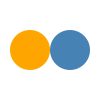

In [31]:
circle = b.element('circle')
orange = circle(cx=30, cy=50, r=20, fill='orange')
blue = circle(cx=70, cy=50, r=20, fill='steelblue')
pic = b.svg(orange, blue, width=200)
pic

The keyword arguments became attributes. System functions read keyword arguments as options:

In [32]:
b.xml(circle(r=10)), b.json('{"a": null}', fill=0)

('<circle r="10"/>', {'a': 0})

CSV options work the same way. `nget` and `nput` read and write files, as in `b.nput(text, path='copy.csv')`:

In [33]:
table = b.csv('price,qty\n10.5,2\n20.0,4\n')
text = b.tocsv(table, separator=';').py
b.csv(text, separator=';').py

{'price': array([10.5, 20. ]), 'qty': array([2, 4])}

`r` compiles a regex into keyed functions, which Python indexes by name:

In [34]:
p = b.r(r'([a-z]+)([0-9]+)')
p['replace']('$2:$1', 'ab12')

12:ab

Legal Python identifiers such as `π` work directly; other glyphs use `getattr(b, '+')`. Existing Python attributes win; glyph/operation names precede unbulleted system names. Thus `apl.binomial` is `!`; use `apl.fn('•binomial')` for the distribution. Lookup uses exact registered names and aliases; unknown names raise `AttributeError`. `dir()` lists available builtins. Workspace variables remain accessible through `apl['name']`.

[Function arrays](glyphs/strand.qmd#function-arrays) retain callable handles. `first` and `pick` return the selected function:

In [35]:
from basedpl import first, pick

In [36]:
fs = apl('+˘×˘÷')
assert pick(2, fs)(2, 3).py == 6
assert first(fs)(2, 3).py == 5

`Array([f, g])` also constructs a function vector; `.py` and object-dtype `.np` export Python callables.

`f.source` returns APL source; `f.inspect()` returns source and help. `apl.names(prefix, classes)` lists visible bindings. `apl.inspect(name)` reads a name or glyph. IPython supports `f?`, `f??` and name completion in `apl` strings. See [names and help](introspection.ipynb).

## Word functions

Primitives also have Python names. Dyadic names bind the right argument when called with one argument; `.left(x)` binds the left.

In [37]:
from basedpl import plus, times, subtract, tally

In [38]:
assert times(2)(3).py == 6
assert subtract(2)(5).py == 3       # 5−2
assert subtract.left(2)(5).py == -3 # 2−5

mean = plus.reduce / tally
assert mean([1, 2, 4]).py == Fraction(7, 3)

Names distinguish valences: `sign`/`times`, `shape`/`reshape`, `iota`/`index_of`, `first`/`take`, `mix`/`pick`. `times(2.)` binds an approximate number; `times(2)` an exact one. Operators use the underlying APL function.

`exponential` and `exponent` name the monadic and dyadic forms of `*`. `power` names the operator `⍣`, exposed as `f.power(n)`. System functions are available by name on the module or `apl`, such as `apl.normal`.

`basedpl.symbols` is the shared naming table used by Python functions and REPL and notebook completion. Each row is `(glyph, name, monad, dyad, aliases, shortcut)`: the canonical glyph name, monadic and dyadic function names (empty when absent), and space-separated extra completion aliases. It includes operators and syntax glyphs too, with empty function names. Python replaces hyphens with underscores and appends an underscore to keywords (`not` → `not_`). `shortcut` is the REPL's formatted Alt-key suffix, derived from `keyboard.json`: `" h"` for Alt-h, `" Sa"` for Alt-Shift-a, or `""` when absent. The table is directly JSON-serializable for JavaScript consumers.

| Python | APL |
|---|---|
| `f.reduce`, `f.scan` | `f/`, `f\` |
| `f.each`, `f.commute` | `f¨`, `f⍨` |
| `f.outer`, `f.inner(g)` | `f⌝`, `f.g` |
| `f.key`, `f.stencil(s)` | `f⌸`, `f⌺s` |
| `f.rank(r)`, `f.atop(g)` | `f⍤r`, `f⍤g` |
| `f.beside(g)`, `f.over(g)`, `f.behind(g)` | `f∘g`, `f⍥g`, `f⍛g` |
| `f.power(n)`, `f.at(i)` | `f⍣n`, `f@i` |
| `f.history(n)` | `f⍣[n]` (count or predicate) |
| `f.with_inverse(g)`, `f.under(g)` | `f⇄g`, `f⌾g` |
| `f.derivative` | `f∂` |
| `f[k]` | `f⍤[k]`, axes `k` |

Operator properties chain in APL order: `subtract.commute.reduce` is `-⍨/`. Operators needing another operand retain a hole until supplied:

In [39]:
twice = times(2)
assert twice.power.each(3)([1, 2]).py.tolist() == [8, 16]  # (twice⍣3)¨

`f.power.each(n)` constructs `(f⍣n)¨`, just like `f.power(n).each`. For multiple missing operands, successive calls fill the innermost construction first: `f.power.each.power(n)(m)` constructs `((f⍣n)¨)⍣m`. Complete the operands before passing evaluation arguments.

Arithmetic between functions makes forks: `f+g` is `(f+g)`. `f @ g` is inner product; `f << g` is compose; `f >> g` reverses composition; `f ** n` is power. Python's precedence applies when building these expressions.

Math families: `prime`/`prime_mode` (`ℙ`), `factors`/`factor_spec` (`⨸`), `polynomial`/`polyval` (`⊛`). `windows` is dyadic `↕`.

Roots: `sqrt`/`root` (`√`). Complex coordinates: `real_imag` (`∨`), `polar` (`∧`), `cis` (`○`). `pi_times`/`pi_ratio` (`π`) give π multiples/fractions. Also `square`, `double`, `decrement`, `increment`, `classify`, `binary_encode` and `binary_decode`.

In [40]:
from basedpl import prime, factors, polyval

In [41]:
assert prime(10).py == 29
np.testing.assert_array_equal(factors(700), [2, 2, 5, 5, 7])
p = polyval.left([1, 2, 3])
assert p(2).py == 17
assert p.derivative(2).py == 14
np.testing.assert_array_equal(p.derivative([10, 20], [1, 2]), [80, 280])
np.testing.assert_array_equal(plus.left(1).history(3)(0), [0, 1, 2, 3])

## Printing functions

`to_python(f)` shows a function using Python word names and combinators.

In [42]:
from basedpl import to_python, plus, times, tally

In [43]:
assert to_python(plus.reduce / tally) == 'plus.reduce / tally'
assert to_python(times(2.)) == 'times(2.)'
assert to_python((plus.reduce / tally).each) == '(plus.reduce / tally).each'

For an ambivalent function, `dyad=True` selects the dyadic spelling. Word functions already specify their valence.

In [44]:
assert to_python(apl('×')) == 'sign'
assert to_python(apl('×'), dyad=True) == 'times'
assert to_python(apl('2∘-')) == 'subtract.left(2.)'
assert to_python(apl('{⍵×2}¨')) == 'fn("{⍵×2}").each'

Dfns and late-bound `.fn(...)` expressions retain their APL source. Use `apl('+/÷≢')` to evaluate a function expression and print its assembled structure. Printing itself never executes APL. Approximate `2` prints as `2.`, exact `2x` as `2`, and fractions as `Fraction(...)`. Complex array constants retain APL notation inside `apl(...)`.

The output is explanatory Python spelling. Python argument evaluation order and workspace definitions remain the caller's responsibility.

## Errors and interruption

`AplError` provides the diagnostic, `kind`, `message`, `source`, byte `span`, call context and prior `output`. Completed assignments survive errors. Capturing calls retain output on the exception; ordinary calls print it before raising.

Ctrl-C interrupts evaluation. From another thread, call `apl.interrupt()`. `apl.timeout = 2` gives each evaluation a two-second deadline. `None`, the default, removes it.

Evaluation runs on the calling thread with the GIL released, so other Python threads keep running. The workspace remains usable after interruption. Native-library calls can delay cancellation. For a hard-kill fallback, use a [process worker](processes.qmd#interruptible-worker).